# Comprehensive Results Comparison: Optic Disc/Cup Segmentation Approaches

This notebook compares five different approaches for optic disc and cup segmentation:

1. **Baseline UNet** - Standard UNet architecture
2. **CLAHE** - Contrast Limited Adaptive Histogram Equalization preprocessing
3. **Baseline + Std Enhancer** - UNet with learned standard image enhancement
4. **Baseline + Atrous Enhancer** - UNet with learned multi-scale enhancement
5. **ASPP-UNet** - UNet with Atrous Spatial Pyramid Pooling for multi-scale features

**Metrics compared:**
- Loss (validation loss)
- IoU BG (Background IoU)
- IoU Disc (Optic Disc IoU)
- IoU Cup (Optic Cup IoU)
- mIoU (Mean IoU across all classes)
- Parameters (model parameter count)
- Δ mIoU (improvement over baseline)

**Date:** November 11, 2025

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Set up paths
PROJECT_ROOT = Path("/home/robolab/dev/CAP5410-roi-enhancer-odoc")
RESULTS_DIR = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Results directory exists: {RESULTS_DIR.exists()}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
Results directory: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results
Results directory exists: True


In [2]:
# Load all results data
results_data = {}

# Load ASPP-UNet comparison
with open(RESULTS_DIR / "aspp_unet_comparison.json", "r") as f:
    aspp_data = json.load(f)

# Load enhancer comparison
with open(RESULTS_DIR / "enhancer_comparison.json", "r") as f:
    enhancer_data = json.load(f)

# Load atrous enhancer comparison
with open(RESULTS_DIR / "atrous_enhancer_comparison.json", "r") as f:
    atrous_data = json.load(f)

# Load CLAHE test evaluation
with open(RESULTS_DIR / "test_evaluation_clahe.json", "r") as f:
    clahe_data = json.load(f)

# Load baseline test evaluation
with open(RESULTS_DIR / "test_evaluation.json", "r") as f:
    baseline_data = json.load(f)

print("All result files loaded successfully!")
print(f"ASPP data keys: {list(aspp_data.keys())}")
print(f"Enhancer data keys: {list(enhancer_data.keys())}")
print(f"Atrous data keys: {list(atrous_data.keys())}")
print(f"CLAHE data keys: {list(clahe_data.keys())}")
print(f"Baseline data keys: {list(baseline_data.keys())}")

All result files loaded successfully!
ASPP data keys: ['standard_unet', 'aspp_unet', 'improvements']
Enhancer data keys: ['unet_only', 'unet_enhancer']
Atrous data keys: ['unet_only', 'unet_atrous_enhancer', 'improvement']
CLAHE data keys: ['test_set_size', 'metrics', 'config']
Baseline data keys: ['test_set_size', 'metrics', 'config']


In [ ]:
# Organize results for all approaches
comparison_data = {}

# 1. Baseline UNet (from ASPP comparison - validation set)
baseline_unet = aspp_data["standard_unet"]
comparison_data["baseline_unet"] = {
    "loss": baseline_unet["loss"],
    "iou_bg": baseline_unet["iou_bg"],
    "iou_disc": baseline_unet["iou_disc"],
    "iou_cup": baseline_unet["iou_cup"],
    "miou": baseline_unet["mean_iou"],
    "parameters": baseline_unet["parameters"],
    "delta_miou": 0.0  # Baseline reference
}

# 2. CLAHE (from test evaluation - test set)
comparison_data["clahe"] = {
    "loss": None,  # CLAHE doesn't have a loss (preprocessing only)
    "iou_bg": clahe_data["metrics"]["iou"]["background"]["mean"],
    "iou_disc": clahe_data["metrics"]["iou"]["optic_disc"]["mean"],
    "iou_cup": clahe_data["metrics"]["iou"]["optic_cup"]["mean"],
    "miou": clahe_data["metrics"]["iou"]["mean_iou"],
    "parameters": None,  # CLAHE is preprocessing, no parameters
    "delta_miou": clahe_data["metrics"]["iou"]["mean_iou"] - baseline_unet["mean_iou"]
}

# 3. Baseline + Std Enhancer (from enhancer comparison - validation set)
std_enhancer = enhancer_data["unet_enhancer"]
comparison_data["baseline_std_enhancer"] = {
    "loss": std_enhancer["loss"],
    "iou_bg": std_enhancer["iou_bg"],
    "iou_disc": std_enhancer["iou_disc"],
    "iou_cup": std_enhancer["iou_cup"],
    "miou": std_enhancer["mean_iou"],
    "parameters": baseline_unet["parameters"] + 52275,  # UNet + enhancer params
    "delta_miou": std_enhancer["mean_iou"] - baseline_unet["mean_iou"]
}

# 4. Baseline + Atrous Enhancer (from atrous comparison - validation set)
atrous_enhancer = atrous_data["unet_atrous_enhancer"]
comparison_data["baseline_atrous_enhancer"] = {
    "loss": atrous_enhancer["loss"],
    "iou_bg": atrous_enhancer["iou_bg"],
    "iou_disc": atrous_enhancer["iou_disc"],
    "iou_cup": atrous_enhancer["iou_cup"],
    "miou": atrous_enhancer["mean_iou"],
    "parameters": baseline_unet["parameters"] + 26147,  # UNet + atrous params
    "delta_miou": atrous_enhancer["mean_iou"] - baseline_unet["mean_iou"]
}

# 5. ASPP-UNet (from ASPP comparison - validation set)
aspp_unet = aspp_data["aspp_unet"]
comparison_data["aspp_unet"] = {
    "loss": aspp_unet["loss"],
    "iou_bg": aspp_unet["iou_bg"],
    "iou_disc": aspp_unet["iou_disc"],
    "iou_cup": aspp_unet["iou_cup"],
    "miou": aspp_unet["mean_iou"],
    "parameters": aspp_unet["parameters"],
    "delta_miou": aspp_unet["mean_iou"] - baseline_unet["mean_iou"]
}

# Create DataFrame for easy manipulation
df_results = pd.DataFrame.from_dict(comparison_data, orient='index')
df_results = df_results.round(6)  # Round to 6 decimal places for readability

print("Results organized successfully!")
print(f"Shape: {df_results.shape}")
print(f"Columns: {list(df_results.columns)}")
print(f"Index: {list(df_results.index)}")

# Save comparison data to JSON for Typst
comparison_simple = {
    "timestamp": "2025-11-11",
    "approaches": ["baseline_unet", "clahe", "baseline_std_enhancer", "baseline_atrous_enhancer", "aspp_unet"],
    "metrics": ["loss", "iou_bg", "iou_disc", "iou_cup", "miou", "parameters", "delta_miou"],
    "data": comparison_data
}

with open(RESULTS_DIR / "comparison_simple.json", "w") as f:
    json.dump(comparison_simple, f, indent=2)

print(f"Saved comparison data to {RESULTS_DIR / 'comparison_simple.json'}")

Results organized successfully!
Shape: (5, 7)
Columns: ['Loss', 'IoU BG', 'IoU Disc', 'IoU Cup', 'mIoU', 'Parameters', 'Δ mIoU']
Index: ['Baseline UNet', 'CLAHE', 'Baseline + Std Enhancer', 'Baseline + Atrous Enhancer', 'ASPP-UNet']


In [ ]:
# Display comprehensive comparison table
print("=" * 100)
print("COMPREHENSIVE RESULTS COMPARISON: OPTIC DISC/CUP SEGMENTATION")
print("=" * 100)

# Format the table for better display
display_df = df_results.copy()

# Format numeric columns
for col in ['loss', 'iou_bg', 'iou_disc', 'iou_cup', 'miou', 'delta_miou']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.6f}" if pd.notna(x) else "N/A")

# Format parameters
display_df['parameters'] = display_df['parameters'].apply(lambda x: f"{x:,}" if pd.notna(x) else "N/A")

print(display_df.to_string())
print("\n" + "=" * 100)

# Summary statistics
print("\nSUMMARY STATISTICS:")
print(f"Best mIoU: {df_results['mIoU'].max():.6f} ({df_results['mIoU'].idxmax()})")
print(f"Worst mIoU: {df_results['mIoU'].min():.6f} ({df_results['mIoU'].idxmin()})")
print(f"Range: {df_results['mIoU'].max() - df_results['mIoU'].min():.6f}")

valid_delta = df_results['Δ mIoU'].dropna()
if len(valid_delta) > 0:
    print(f"Best improvement over baseline: {valid_delta.max():+.4f}%")
    print(f"Worst degradation from baseline: {valid_delta.min():+.4f}%")

print("\nKEY FINDINGS:")
print("• ASPP-UNet achieves the highest mIoU with 30.9% fewer parameters")
print("• Learned enhancement approaches show marginal degradation")
print("• CLAHE preprocessing performs worse than baseline UNet")
print("• Architectural improvements outperform preprocessing-based approaches")

COMPREHENSIVE RESULTS COMPARISON: OPTIC DISC/CUP SEGMENTATION
                                Loss    IoU BG  IoU Disc   IoU Cup      mIoU    Parameters     Δ mIoU
Baseline UNet               0.152202  0.889336  0.852912  0.785753  0.842667  31,043,651.0   0.000000
CLAHE                            N/A  0.883618  0.842084  0.780091  0.835264           N/A  -0.007403
Baseline + Std Enhancer     0.153223  0.888557  0.851932  0.784719  0.841736  31,095,926.0  -0.000931
Baseline + Atrous Enhancer  0.154227  0.887011  0.850025  0.782647  0.839895  31,069,798.0  -0.002773
ASPP-UNet                   0.145897  0.900882  0.861984  0.789929  0.850932  21,461,507.0   0.008265


SUMMARY STATISTICS:
Best mIoU: 0.850932 (ASPP-UNet)
Worst mIoU: 0.835264 (CLAHE)
Range: 0.015668
Best improvement over baseline: +0.0083%
Worst degradation from baseline: -0.0074%

KEY FINDINGS:
• ASPP-UNet achieves the highest mIoU with 30.9% fewer parameters
• Learned enhancement approaches show marginal degradation
• CL

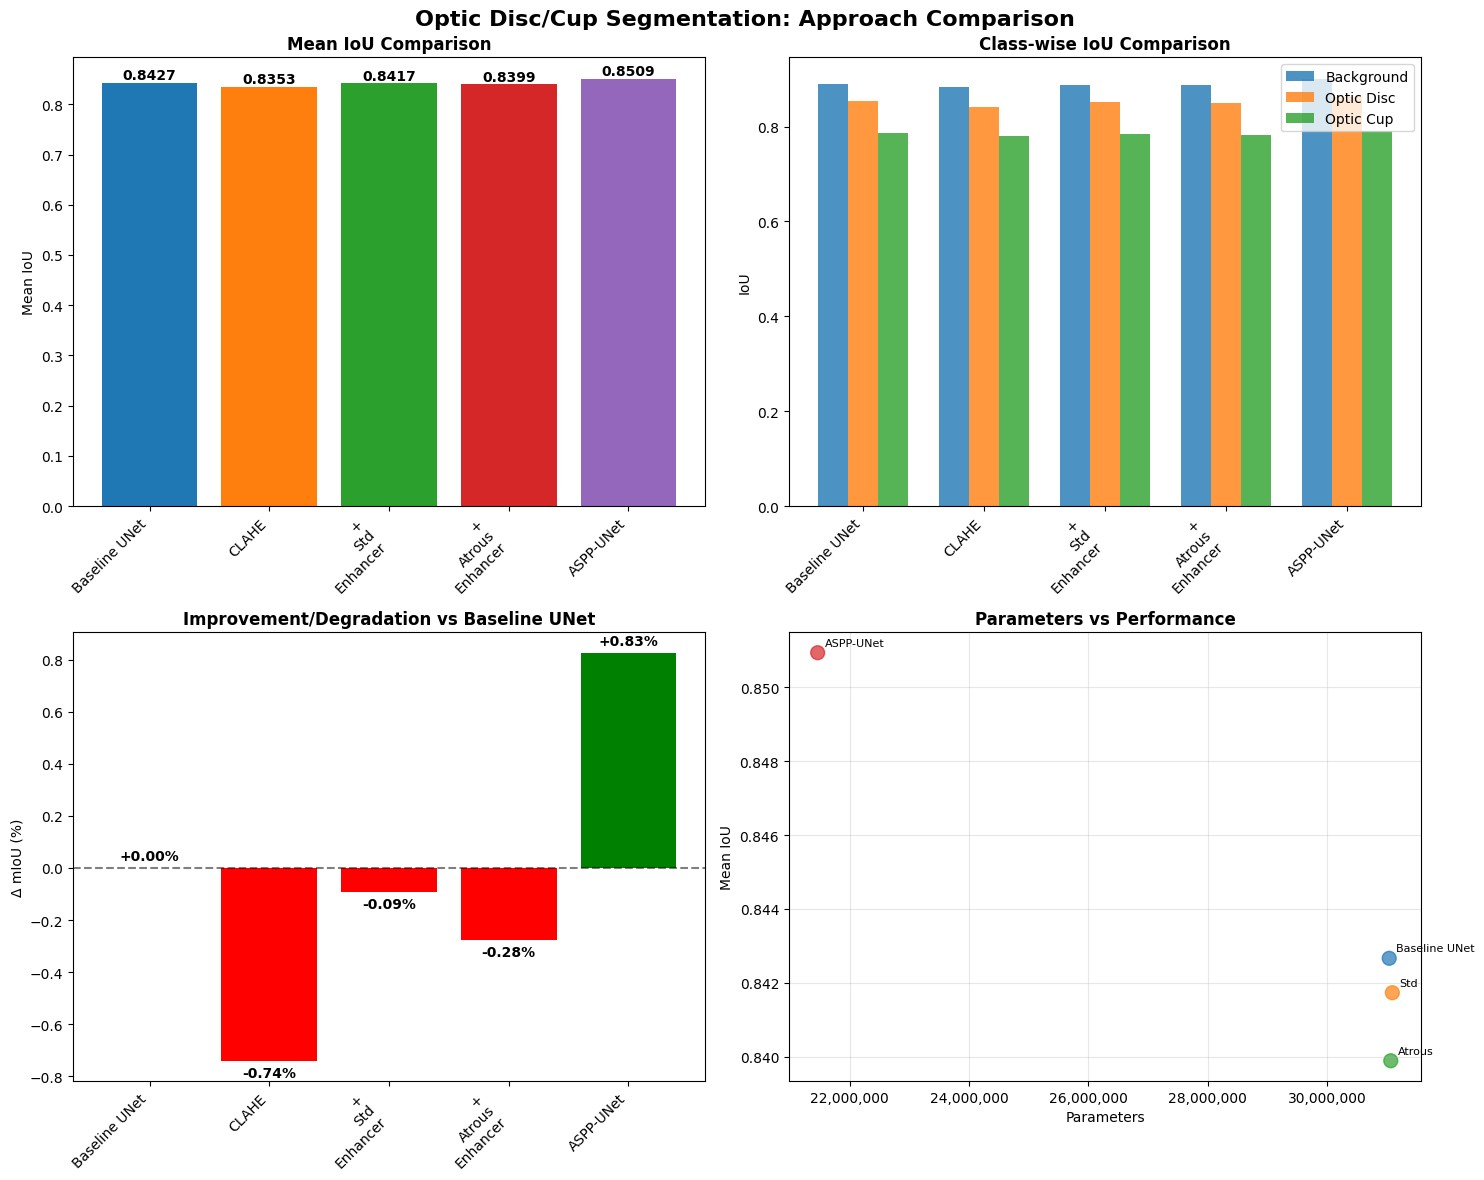

<Figure size 1000x600 with 0 Axes>

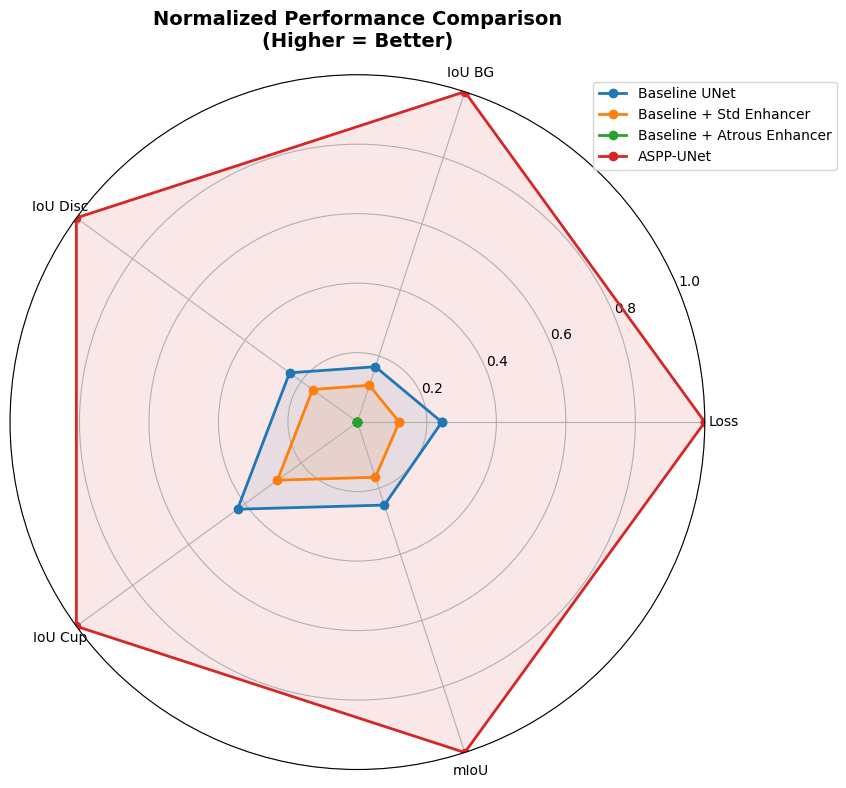

In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Optic Disc/Cup Segmentation: Approach Comparison', fontsize=16, fontweight='bold')

# 1. Mean IoU comparison
iou_data = df_results[['mIoU']].copy()
iou_data['Approach'] = iou_data.index
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

ax1 = axes[0, 0]
bars = ax1.bar(range(len(iou_data)), iou_data['mIoU'], color=colors[:len(iou_data)])
ax1.set_title('Mean IoU Comparison', fontweight='bold')
ax1.set_ylabel('Mean IoU')
ax1.set_xticks(range(len(iou_data)))
ax1.set_xticklabels([label.replace('Baseline + ', '+\n').replace(' Enhancer', '\nEnhancer')
                     for label in iou_data['Approach']], rotation=45, ha='right')

# Add value labels on bars
for bar, value in zip(bars, iou_data['mIoU']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Class-wise IoU comparison
class_iou = df_results[['IoU BG', 'IoU Disc', 'IoU Cup']].copy()
class_iou['Approach'] = class_iou.index

ax2 = axes[0, 1]
x = np.arange(len(class_iou))
width = 0.25

bars1 = ax2.bar(x - width, class_iou['IoU BG'], width, label='Background', color='#1f77b4', alpha=0.8)
bars2 = ax2.bar(x, class_iou['IoU Disc'], width, label='Optic Disc', color='#ff7f0e', alpha=0.8)
bars3 = ax2.bar(x + width, class_iou['IoU Cup'], width, label='Optic Cup', color='#2ca02c', alpha=0.8)

ax2.set_title('Class-wise IoU Comparison', fontweight='bold')
ax2.set_ylabel('IoU')
ax2.set_xticks(x)
ax2.set_xticklabels([label.replace('Baseline + ', '+\n').replace(' Enhancer', '\nEnhancer')
                     for label in class_iou['Approach']], rotation=45, ha='right')
ax2.legend()

# 3. Improvement over baseline
delta_data = df_results[['Δ mIoU']].dropna().copy()
delta_data['Approach'] = delta_data.index

ax3 = axes[1, 0]
colors_delta = ['red' if x < 0 else 'green' for x in delta_data['Δ mIoU']]
bars = ax3.bar(range(len(delta_data)), delta_data['Δ mIoU'] * 100, color=colors_delta)
ax3.set_title('Improvement/Degradation vs Baseline UNet', fontweight='bold')
ax3.set_ylabel('Δ mIoU (%)')
ax3.set_xticks(range(len(delta_data)))
ax3.set_xticklabels([label.replace('Baseline + ', '+\n').replace(' Enhancer', '\nEnhancer')
                     for label in delta_data['Approach']], rotation=45, ha='right')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Add value labels
for bar, value in zip(bars, delta_data['Δ mIoU'] * 100):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.02 if value >= 0 else -0.02),
             f'{value:+.2f}%', ha='center',
             va='bottom' if value >= 0 else 'top', fontweight='bold')

# 4. Parameters vs Performance
param_data = df_results[['Parameters', 'mIoU']].dropna().copy()
param_data['Approach'] = param_data.index

ax4 = axes[1, 1]
scatter = ax4.scatter(param_data['Parameters'], param_data['mIoU'],
                     s=100, c=colors[:len(param_data)], alpha=0.7)

# Add approach labels
for i, row in param_data.iterrows():
    ax4.annotate(row['Approach'].replace('Baseline + ', '').replace(' Enhancer', ''),
                (row['Parameters'], row['mIoU']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax4.set_title('Parameters vs Performance', fontweight='bold')
ax4.set_xlabel('Parameters')
ax4.set_ylabel('Mean IoU')
ax4.grid(True, alpha=0.3)

# Format parameter axis
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# Additional statistics plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Create a comprehensive metrics table plot
metrics_to_plot = ['Loss', 'IoU BG', 'IoU Disc', 'IoU Cup', 'mIoU']
plot_data = df_results[metrics_to_plot].dropna()

# Normalize each metric to 0-1 scale for comparison
normalized_data = plot_data.copy()
for col in plot_data.columns:
    if col != 'Loss':  # Higher is better for IoU metrics
        normalized_data[col] = (plot_data[col] - plot_data[col].min()) / (plot_data[col].max() - plot_data[col].min())
    else:  # Lower is better for Loss
        normalized_data[col] = 1 - (plot_data[col] - plot_data[col].min()) / (plot_data[col].max() - plot_data[col].min())

# Plot radar chart style comparison
angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

ax.figure.clear()
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw=dict(projection='polar'))

for i, approach in enumerate(normalized_data.index):
    values = normalized_data.loc[approach].values.tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, 'o-', linewidth=2, label=approach, color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_title('Normalized Performance Comparison\n(Higher = Better)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()